<a href="https://colab.research.google.com/github/yunusemrearslan37/Duygu_siniflandirma/blob/master/Dogal_dil_proje2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%pip install -q openpyxl evaluate transformers datasets accelerate scikit-learn deep-translator


In [ ]:
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DOSYA_YOLU = "/content/drive/MyDrive/Dogal_dil/Last_HouseMD_DataSet.xlsx"

veri = pd.read_excel(DOSYA_YOLU)
veri = veri[["text", "Emotion"]].dropna()

veri["text"] = veri["text"].astype(str).str.strip()
veri["Emotion"] = veri["Emotion"].astype(str).str.lower().str.strip()

duygu_haritasi = {
    'acı dolu': 'acı_uzuntu', 'acı içinde': 'acı_uzuntu', 'acı çeken': 'acı_uzuntu',
    'acılı': 'acı_uzuntu', 'ızdırap': 'acı_uzuntu', 'hüzün': 'acı_uzuntu',
    'hüzünlü': 'acı_uzuntu', 'keder': 'acı_uzuntu', 'hayal kırıklığı': 'acı_uzuntu',
    'mutsuz': 'acı_uzuntu', 'mutsuzluk': 'acı_uzuntu', 'ağlamaklı': 'acı_uzuntu',
    'boşluk': 'acı_uzuntu', 'karamsar': 'acı_uzuntu', 'umutsuzluk': 'acı_uzuntu',
    'acı': 'acı_uzuntu', 'sinirli': 'ofke_sinir', 'kızgın': 'ofke_sinir',
    'irritasyon': 'ofke_sinir', 'düşmanca': 'ofke_sinir', 'sert': 'ofke_sinir',
    'zalim': 'ofke_sinir', 'iğrenme': 'ofke_sinir', 'iğneleyici': 'ofke_sinir',
    'alaycı': 'ofke_sinir', 'küçümseyici': 'ofke_sinir', 'kibirli': 'ofke_sinir',
    'itiraz': 'ofke_sinir', 'itiraz eden': 'ofke_sinir', 'itirazcı': 'ofke_sinir',
    'suçlu': 'ofke_sinir', 'suçluluk': 'ofke_sinir', 'karşıt': 'ofke_sinir',
    'korku': 'korku_endise', 'korkmuş': 'korku_endise', 'korkutucu': 'korku_endise',
    'korkulu': 'korku_endise', 'endişe': 'korku_endise', 'endişeli': 'korku_endise',
    'kaygı': 'korku_endise', 'kaygılı': 'korku_endise', 'gergin': 'korku_endise',
    'panik': 'korku_endise', 'tedirgin': 'korku_endise', 'telaşlı': 'korku_endise',
    'stres': 'korku_endise', 'stresli': 'korku_endise', 'dehşete düşmüş': 'korku_endise',
    'kuşkulu': 'korku_endise', 'mutlu': 'mutluluk_rahatlama', 'mutluluk': 'mutluluk_rahatlama',
    'sevinç': 'mutluluk_rahatlama', 'memnun': 'mutluluk_rahatlama', 'rahat': 'mutluluk_rahatlama',
    'rahatlama': 'mutluluk_rahatlama', 'rahatlamış': 'mutluluk_rahatlama', 'rahatlatıcı': 'mutluluk_rahatlama',
    'umut': 'mutluluk_rahatlama', 'umutlu': 'mutluluk_rahatlama', 'heyecan': 'mutluluk_rahatlama',
    'heyecanlı': 'mutluluk_rahatlama', 'hevesli': 'mutluluk_rahatlama', 'muzaffer': 'mutluluk_rahatlama',
    'olumlu': 'mutluluk_rahatlama', 'enerjik': 'mutluluk_rahatlama', 'nükteli': 'mutluluk_rahatlama',
    'esprili': 'mutluluk_rahatlama', 'kafası karışık': 'kafa_karisikligi', 'kararsız': 'kafa_karisikligi',
    'emin olmayan': 'kafa_karisikligi', 'mahcup': 'kafa_karisikligi', 'nötr': 'notr_analitik',
    'nört': 'notr_analitik', 'tarafsız': 'notr_analitik', 'ciddi': 'notr_analitik',
    'ciddiyet': 'notr_analitik', 'analitik': 'notr_analitik', 'bilgilendirici': 'notr_analitik',
    'bilgi verici': 'notr_analitik', 'bilimsel': 'notr_analitik', 'resmi': 'notr_analitik',
    'net': 'notr_analitik', 'gerçekçi': 'notr_analitik', 'profesyonel': 'notr_analitik',
    'mantıklı': 'notr_analitik', 'pratik': 'notr_analitik', 'hesaplanmış': 'notr_analitik',
    'bilgili': 'notr_analitik', 'bilgiç': 'notr_analitik', 'empati': 'empati_destek',
    'anlayışlı': 'empati_destek', 'yardımsever': 'empati_destek', 'destekleyici': 'empati_destek',
    'fedakar': 'empati_destek', 'güven verici': 'empati_destek', 'güvence_verici': 'empati_destek',
    'güven': 'empati_destek', 'savunmacı': 'empati_destek', 'onaylayıcı': 'empati_destek',
    'minnettar': 'empati_destek', 'etkilenmiş': 'empati_destek', 'yorgunluk': 'yorgunluk_bikkinlik',
    'bitkin': 'yorgunluk_bikkinlik', 'halsizlik': 'yorgunluk_bikkinlik', 'bıkkın': 'yorgunluk_bikkinlik',
    'bıkkınlık': 'yorgunluk_bikkinlik', 'sıkılmış': 'yorgunluk_bikkinlik', 'kayıtsız': 'yorgunluk_bikkinlik',
    'umursamaz': 'yorgunluk_bikkinlik', 'rahatsız': 'yorgunluk_bikkinlik', 'rahatsızlık': 'yorgunluk_bikkinlik',
    'merak': 'merak_odak', 'meraklı': 'merak_odak', 'sorgulayıcı': 'merak_odak', 'soru soran': 'merak_odak',
    'düşünceli': 'merak_odak', 'araştırmacı': 'merak_odak', 'odaklanmış': 'merak_odak',
    'konsantrasyon': 'merak_odak', 'dikkatli': 'merak_odak', 'gözlemci': 'merak_odak',
    'aydınlanma': 'merak_odak', 'aydınlanmış': 'merak_odak', 'açıklayıcı': 'merak_odak',
    'gizemli': 'merak_odak', 'kendinden emin': 'otoriter_ozguvenli', 'emin': 'otoriter_ozguvenli',
    'kararlı': 'otoriter_ozguvenli', 'otoriter': 'otoriter_ozguvenli', 'emir': 'otoriter_ozguvenli',
    'emredici': 'otoriter_ozguvenli', 'iddialı': 'otoriter_ozguvenli', 'meydan okuyan': 'otoriter_ozguvenli',
    'ikna edici': 'otoriter_ozguvenli', 'cesur': 'otoriter_ozguvenli', 'inatçı': 'otoriter_ozguvenli',
    'manipülatif': 'otoriter_ozguvenli', 'acil': 'acil_durum', 'aceleci': 'acil_durum',
    'hızlı': 'acil_durum', 'uyarıcı': 'acil_durum', 'sabırsızlık': 'acil_durum',
    'hasta': 'fiziksel_durum', 'cilt': 'fiziksel_durum', 'solunum': 'fiziksel_durum', 'aç': 'fiziksel_durum'
}

veri["Emotion"] = veri["Emotion"].replace(duygu_haritasi)

son_etiket_birlestir = {
    "öfke": "ofke_sinir",
    "öfkeli": "ofke_sinir",
    "şikayetçi": "ofke_sinir",
    "ukala": "ofke_sinir",
    "üzgün": "acı_uzuntu",
    "üzüntü": "acı_uzuntu",
    "ümitsizlik": "acı_uzuntu",
    "çaresiz": "acı_uzuntu",
    "ümutsuz": "acı_uzuntu",
    "kötü": "acı_uzuntu",
    "şaşkın": "kafa_karisikligi",
    "şaşkınlık": "kafa_karisikligi",
    "şok": "korku_endise",
    "şüphe": "merak_odak",
    "şüpheci": "merak_odak",
    "yorgun": "yorgunluk_bikkinlik",
    "zafer": "mutluluk_rahatlama",
    "sakin": "notr_analitik",
}

veri["Emotion"] = veri["Emotion"].replace(son_etiket_birlestir)

MIN_ORNEK = 8
while True:
    frekans = veri["Emotion"].value_counts()
    nadir = frekans[frekans < MIN_ORNEK].index.tolist()
    if not nadir:
        break
    veri.loc[veri["Emotion"].isin(nadir), "Emotion"] = "diger"

metinler = veri["text"].tolist()
duygular = veri["Emotion"].tolist()

etiket_kodlayici = LabelEncoder()
y = etiket_kodlayici.fit_transform(duygular)
sinif_sayisi = len(etiket_kodlayici.classes_)

print("Örnek:", len(veri), "| Sınıf:", sinif_sayisi)
print(etiket_kodlayici.classes_)

TEST_ORANI = 0.15
x_calisma, x_test_fin, y_calisma, y_test_fin = train_test_split(
    metinler,
    y,
    test_size=TEST_ORANI,
    random_state=RANDOM_STATE,
    stratify=y,
)

VALID_ICI_ORAN = TEST_ORANI / (1 - TEST_ORANI)
x_train, x_val, y_train, y_val = train_test_split(
    x_calisma,
    y_calisma,
    test_size=VALID_ICI_ORAN,
    random_state=RANDOM_STATE,
    stratify=y_calisma,
)

print(len(x_train), "eğitim |", len(x_val), "doğrulama |", len(x_test_fin), "nihai test")


Örnek: 7279 | Sınıf: 12
['acil_durum' 'acı_uzuntu' 'diger' 'empati_destek' 'kafa_karisikligi'
 'korku_endise' 'merak_odak' 'mutluluk_rahatlama' 'notr_analitik'
 'ofke_sinir' 'otoriter_ozguvenli' 'yorgunluk_bikkinlik']
5095 eğitim | 1092 doğrulama | 1092 nihai test


In [ ]:
import time
import numpy as np
import pandas as pd
from deep_translator import GoogleTranslator
from datasets import Dataset
from transformers import AutoTokenizer

# --- 1. VERİ ARTIRMA (BACK-TRANSLATION) BAŞLANGICI ---
print("Azınlık sınıflar için veri artırma işlemi (Back-Translation) başlatılıyor...")
train_df = pd.DataFrame({'text': x_train, 'label': y_train})
class_counts = train_df['label'].value_counts()

# Sınıf frekansı 100'den az olanları azınlık sınıfı olarak belirliyoruz
minority_classes = class_counts[class_counts < 100].index.tolist()

augmented_texts = []
augmented_labels = []

translator_to_en = GoogleTranslator(source='tr', target='en')
translator_to_tr = GoogleTranslator(source='en', target='tr')

for label in minority_classes:
    minority_texts = train_df[train_df['label'] == label]['text'].tolist()
    for text in minority_texts:
        try:
            # Metni İngilizce'ye, sonra tekrar Türkçe'ye çevir
            en_text = translator_to_en.translate(text)
            tr_text = translator_to_tr.translate(en_text)
            # Anlamlı bir metin elde ettiysek ve orijinalinden farklıysa ekle
            if tr_text and len(tr_text) > 2 and tr_text.lower() != text.lower():
                augmented_texts.append(tr_text)
                augmented_labels.append(label)
        except Exception:
            pass
        # Çeviri servisi API limitine takılmamak için kısa bekleme
        time.sleep(0.1)

# Yeni üretilen sentetik verileri eğitim setine (x_train, y_train) ekleyelim
if augmented_texts:
    x_train.extend(augmented_texts)
    y_train = np.concatenate([y_train, augmented_labels])
    print(f"Toplam {len(augmented_texts)} yeni sentetik veri eklendi.")
# --- VERİ ARTIRMA BİTİŞİ ---

MODEL_NAME = "dbmdz/bert-base-turkish-cased"
MAX_SEQUENCE_LENGTH = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_SEQUENCE_LENGTH,
    )

ds_train = Dataset.from_dict({"text": x_train, "label": y_train})
ds_val = Dataset.from_dict({"text": x_val, "label": y_val})
ds_test_holdout = Dataset.from_dict({"text": x_test_fin, "label": y_test_fin})

tok_train = ds_train.map(tokenize_fn, batched=True, remove_columns=["text"])
tok_val = ds_val.map(tokenize_fn, batched=True, remove_columns=["text"])
tok_test_holdout = ds_test_holdout.map(tokenize_fn, batched=True, remove_columns=["text"])


Azınlık sınıflar için veri artırma işlemi (Back-Translation) başlatılıyor...
Toplam 242 yeni sentetik veri eklendi.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/5337 [00:00<?, ? examples/s]

Map:   0%|          | 0/1092 [00:00<?, ? examples/s]

Map:   0%|          | 0/1092 [00:00<?, ? examples/s]

In [ ]:
import numpy as np
import torch
import evaluate
import torch.nn.functional as F
from torch import nn
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    AutoModelForSequenceClassification,
    EarlyStoppingCallback,
    TrainingArguments,
    Trainer,
    set_seed,
)

set_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dropout oranlarını varsayılan (%10) seviyesine çekiyoruz
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=sinif_sayisi,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1
)
model.to(DEVICE)

accuracy_metrik = evaluate.load("accuracy")
f1_metrik = evaluate.load("f1")

def basari_hesapla(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    metrikler = {
        "accuracy": accuracy_metrik.compute(predictions=preds, references=labels)["accuracy"],
        "f1": f1_metrik.compute(predictions=preds, references=labels, average="weighted")["f1"],
        "f1_macro": f1_metrik.compute(predictions=preds, references=labels, average="macro")[
            "f1"
        ],
    }
    return metrikler


sinif_np = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
sinif_torch = torch.tensor(sinif_np, dtype=torch.float32, device=DEVICE)

# Sınıf dengesizliği ile daha yumuşak başa çıkmak için Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.weight = weight
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

class AgirlikliTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        w = sinif_torch.to(logits.device, dtype=torch.float32)
        # Normal CrossEntropyLoss yerine FocalLoss kullanılıyor
        loss_fct = FocalLoss(weight=w, gamma=2.0)
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


use_bf16 = bool(torch.cuda.is_available() and torch.cuda.is_bf16_supported())
use_fp16 = bool(torch.cuda.is_available() and not use_bf16)

TRAIN_BS = 16  # CUDA OOM: 8 yap
EVAL_BS = 32
ACC_STEPS = 2

EARLY_STOP = 4
NUM_EPOCH_MAX = 12

ayarlar = TrainingArguments(
    output_dir="./model_cikti",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=75,
    learning_rate=3e-5,          # LR artırıldı (daha hızlı öğrenebilmesi için)
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    weight_decay=0.01,           # Weight decay tekrar yumuşatıldı
    bf16=use_bf16,
    fp16=use_fp16,
    gradient_accumulation_steps=ACC_STEPS,
    optim="adamw_torch",
    max_grad_norm=1.0,
    per_device_train_batch_size=TRAIN_BS,
    per_device_eval_batch_size=EVAL_BS,
    gradient_checkpointing=False,
    dataloader_pin_memory=torch.cuda.is_available(),
    dataloader_num_workers=0,
    num_train_epochs=NUM_EPOCH_MAX,
    metric_for_best_model="eval_f1",
    greater_is_better=True,
    load_best_model_at_end=True,
    save_total_limit=2,
    report_to="none",
)

callbacks = [EarlyStoppingCallback(early_stopping_patience=EARLY_STOP)]

egitmen = AgirlikliTrainer(
    model=model,
    args=ayarlar,
    train_dataset=tok_train,
    eval_dataset=tok_val,
    compute_metrics=basari_hesapla,
    callbacks=callbacks,
)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dbmdz/bert-base-turkish-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecate

In [ ]:
egitmen.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1,F1 Macro
1,4.316078,1.756711,0.054945,0.010371,0.015996
2,3.889149,1.556248,0.112637,0.061502,0.100561
3,2.862702,1.380190,0.136447,0.082901,0.143075
4,1.648447,1.449911,0.140110,0.089644,0.154496
5,0.552814,1.635896,0.151099,0.091814,0.149433
6,0.202697,1.853196,0.183150,0.139607,0.142736
7,0.082195,2.087878,0.306777,0.335923,0.171755
8,0.047711,2.207027,0.400183,0.440366,0.210945
9,0.013745,2.301984,0.413919,0.453664,0.197530
10,0.010098,2.313344,0.454212,0.493708,0.207459


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=2004, training_loss=1.168600564885758, metrics={'train_runtime': 241.3661, 'train_samples_per_second': 265.34, 'train_steps_per_second': 8.303, 'total_flos': 8426098692218880.0, 'train_loss': 1.168600564885758, 'epoch': 12.0})

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

print("Nihai test (Held-out küme — eğitim ve doğrulamaya hiç girmedi):", egitmen.evaluate(eval_dataset=tok_test_holdout))

pred_out = egitmen.predict(tok_test_holdout)
y_hat = np.argmax(pred_out.predictions, axis=-1)
y_ok = tok_test_holdout["label"]

print(
    classification_report(
        y_ok,
        y_hat,
        labels=list(range(len(etiket_kodlayici.classes_))),
        target_names=etiket_kodlayici.classes_,
        zero_division=0,
    )
)


Nihai test (Held-out küme — eğitim ve doğrulamaya hiç girmedi): {'eval_loss': 2.4170422554016113, 'eval_accuracy': 0.4532967032967033, 'eval_f1': 0.4933901681903423, 'eval_f1_macro': 0.2090707669180776, 'eval_runtime': 1.0897, 'eval_samples_per_second': 1002.126, 'eval_steps_per_second': 32.119, 'epoch': 12.0}
                     precision    recall  f1-score   support

         acil_durum       0.04      0.08      0.06        13
         acı_uzuntu       0.21      0.33      0.25        24
              diger       0.00      0.00      0.00         8
      empati_destek       0.13      0.23      0.17        13
   kafa_karisikligi       0.10      0.07      0.08        15
       korku_endise       0.25      0.54      0.34       112
         merak_odak       0.18      0.41      0.26        29
 mutluluk_rahatlama       0.16      0.18      0.17        22
      notr_analitik       0.78      0.50      0.61       732
         ofke_sinir       0.34      0.39      0.36        59
 otoriter_ozguve

In [ ]:
import torch
import torch.nn.functional as F

model.eval()

test_cumlesi = "Çok heyecanlıyım"

inputs = tokenizer(
    test_cumlesi,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=MAX_SEQUENCE_LENGTH,
)
inputs = {k: v.to(model.device) for k, v in inputs.items()}

with torch.no_grad():
    logits = model(**inputs).logits[0]

probs = F.softmax(logits, dim=-1)
best_val, idx = probs.max(dim=-1)
isim = etiket_kodlayici.inverse_transform([idx.item()])[0]
print(f"Cümle: {test_cumlesi!r} -> {isim} (olasılık ~ {best_val.item():.3f})")

k = min(5, len(etiket_kodlayici.classes_))
tops = torch.topk(probs, k=k)
print("Üst-" + str(k) + ":")
for val, ix in zip(tops.values.tolist(), tops.indices.tolist()):
    name = etiket_kodlayici.inverse_transform([ix])[0]
    print(f"  {name}: {val:.3f}")


Cümle: 'Çok heyecanlıyım' -> mutluluk_rahatlama (olasılık ~ 0.313)
Üst-5:
  mutluluk_rahatlama: 0.313
  acı_uzuntu: 0.255
  diger: 0.155
  notr_analitik: 0.112
  korku_endise: 0.081


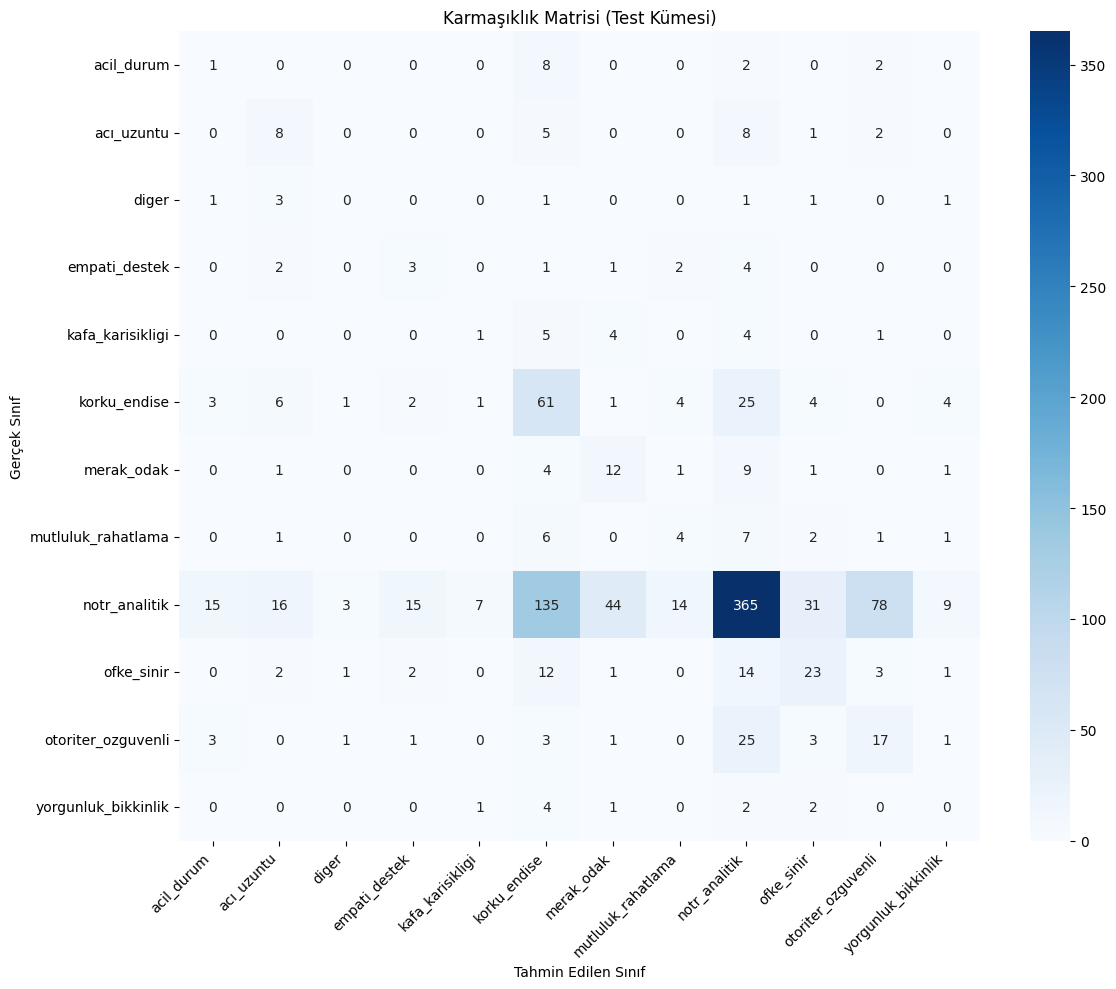

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Karmaşıklık Matrisi (Confusion Matrix)
cm = confusion_matrix(y_ok, y_hat)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=etiket_kodlayici.classes_,
    yticklabels=etiket_kodlayici.classes_
)
plt.xlabel('Tahmin Edilen Sınıf')
plt.ylabel('Gerçek Sınıf')
plt.title('Karmaşıklık Matrisi (Test Kümesi)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

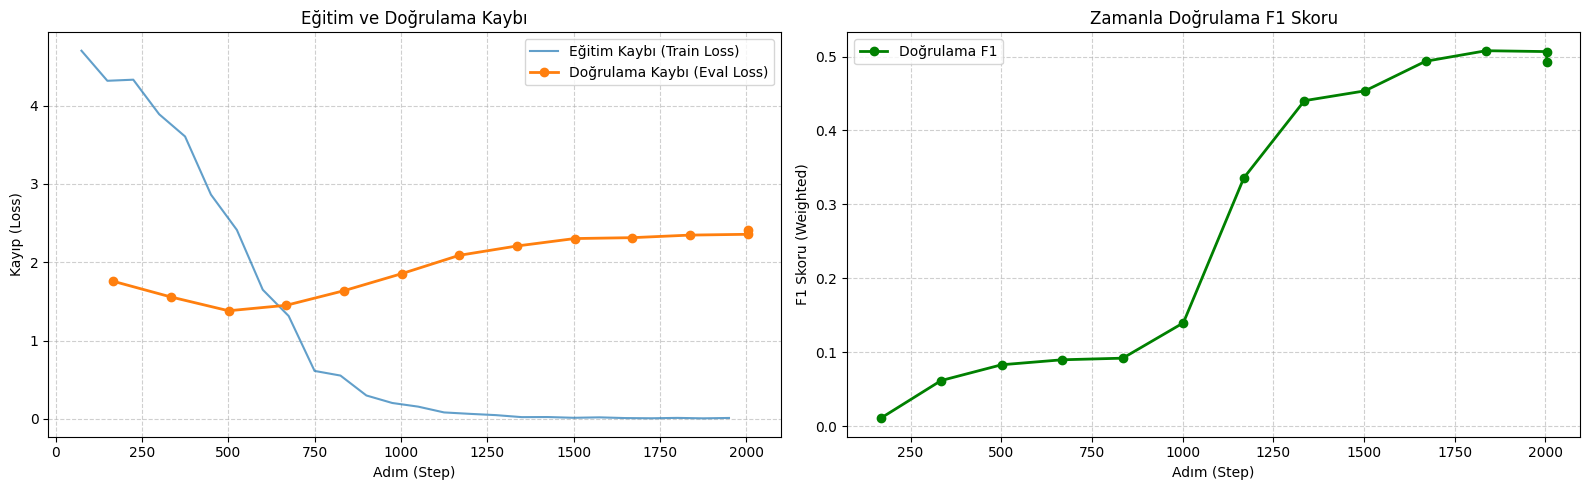

In [ ]:
# Eğitim ve Doğrulama (Validation) Metriklerinin Grafikleri
log_df = pd.DataFrame(egitmen.state.log_history)

train_loss = log_df[log_df['loss'].notna()]
eval_metrics = log_df[log_df['eval_loss'].notna()]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Grafik: Kayıp (Loss)
if not train_loss.empty:
    axes[0].plot(train_loss['step'], train_loss['loss'], label='Eğitim Kaybı (Train Loss)', alpha=0.7)
if not eval_metrics.empty:
    axes[0].plot(eval_metrics['step'], eval_metrics['eval_loss'], label='Doğrulama Kaybı (Eval Loss)', marker='o', linewidth=2)
axes[0].set_xlabel('Adım (Step)')
axes[0].set_ylabel('Kayıp (Loss)')
axes[0].set_title('Eğitim ve Doğrulama Kaybı')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. Grafik: F1 Skoru
if not eval_metrics.empty and 'eval_f1' in eval_metrics.columns:
    axes[1].plot(eval_metrics['step'], eval_metrics['eval_f1'], label='Doğrulama F1', marker='o', color='green', linewidth=2)
    axes[1].set_xlabel('Adım (Step)')
    axes[1].set_ylabel('F1 Skoru (Weighted)')
    axes[1].set_title('Zamanla Doğrulama F1 Skoru')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()